                    АНАЛИЗ СЕТЕВОГО ДАМПА
Файл: Test.pcap
Размер: 996761 байт

DNS ЗАПРОСЫ

Топ DNS запросов:

IP АДРЕСА

Все IP:
   2163 - 192.168.76.131
    596 - 13.107.21.200
    279 - 192.168.76.2
    249 - 65.55.163.76
    185 - 52.229.207.60
    113 - 204.79.197.203
     88 - 140.82.59.185
     63 - 52.114.128.43
     59 - 172.217.31.5
     50 - 52.230.85.180
     39 - 52.232.69.150
     39 - 117.18.232.200
     36 - 13.107.3.128
     31 - 52.109.120.21
     30 - 111.221.29.174

ПРОТОКОЛЫ
  TCP: 1856 пакетов
  UDP: 341 пакетов
  DNS: 279 пакетов
  HTTP: 18 пакетов
  ARP: 0 пакетов

СОЕДИНЕНИЯ
    319 - 13.107.21.200 -> 192.168.76.131
    277 - 192.168.76.131 -> 13.107.21.200
    163 - 65.55.163.76 -> 192.168.76.131
    141 - 192.168.76.2 -> 192.168.76.131
    138 - 192.168.76.131 -> 192.168.76.2
     94 - 52.229.207.60 -> 192.168.76.131
     91 - 192.168.76.131 -> 52.229.207.60
     86 - 192.168.76.131 -> 65.55.163.76
     79 - 204.79.197.203 -> 192.168.76.131
     46 - 192.168.

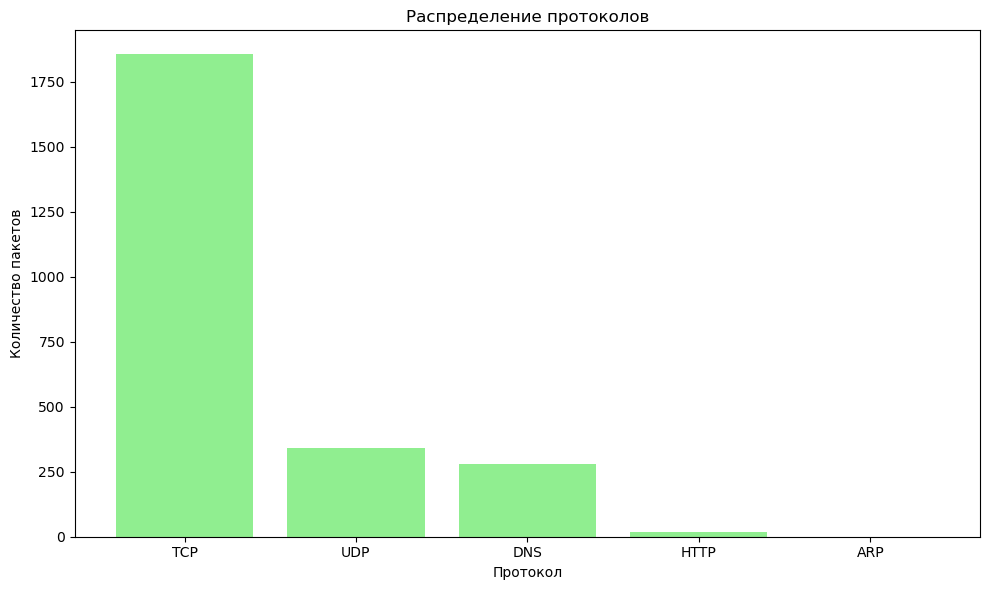

✓ protocols.png

ВРЕМЕННАЯ ШКАЛА
Собрано пакетов: 0
Нет данных для временной шкалы

СОХРАНЕНИЕ
✓ analysis_results.json
✓ analysis_report.txt

                         ГОТОВО


In [18]:
import subprocess
import matplotlib.pyplot as plt
from datetime import datetime
import json
import os
from collections import Counter
import sys

# ============================================
# АНАЛИЗ СЕТЕВОГО ДАМПА (УПРОЩЕННАЯ ВЕРСИЯ)
# ============================================

class TsharkAnalyzer:
    def __init__(self, pcap_file):
        self.pcap_file = pcap_file
        self.tshark = r'C:\Program Files\Wireshark\tshark.exe'
        self.results = {
            'dns': [],
            'ips': {},
            'protocols': {},
            'conversations': []
        }
        
    def run(self, cmd):
        """Запуск команды с игнорированием ошибок кодировки"""
        try:
            # Используем binary mode и игнорируем ошибки
            result = subprocess.run(cmd, shell=True, capture_output=True)
            # Пробуем разные кодировки
            for encoding in ['utf-8', 'cp1251', 'latin-1', 'ascii']:
                try:
                    return result.stdout.decode(encoding, errors='ignore')
                except:
                    continue
            return result.stdout.decode('utf-8', errors='ignore')
        except Exception as e:
            print(f"Ошибка: {e}")
            return ""
    
    def get_dns(self):
        """DNS запросы"""
        print("\n" + "="*60)
        print("DNS ЗАПРОСЫ")
        print("="*60)
        
        # Простой запрос DNS имен
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y dns.qry.name -T fields -e dns.qry.name -e ip.src | findstr /v "^$" | head -50'
        output = self.run(cmd)
        
        dns_list = []
        for line in output.split('\n'):
            if line.strip():
                parts = line.split('\t')
                if len(parts) >= 1:
                    domain = parts[0].strip()
                    src = parts[1] if len(parts) > 1 else "unknown"
                    if domain:
                        dns_list.append({'domain': domain, 'src': src})
                        print(f"  {domain} (from {src})")
        
        # Считаем топ
        domains = [d['domain'] for d in dns_list]
        top_domains = Counter(domains).most_common(15)
        
        print("\nТоп DNS запросов:")
        for domain, count in top_domains:
            print(f"  {count:>3} - {domain}")
        
        self.results['dns'] = [{'domain': d, 'count': c} for d, c in top_domains]
        return top_domains
    
    def get_ips(self):
        """IP статистика"""
        print("\n" + "="*60)
        print("IP АДРЕСА")
        print("="*60)
        
        cmd = f'"{self.tshark}" -r {self.pcap_file} -T fields -e ip.src -e ip.dst | findstr /v "^$"'
        output = self.run(cmd)
        
        all_ips = []
        src_ips = []
        dst_ips = []
        
        for line in output.split('\n'):
            if line.strip():
                if '\t' in line:
                    src, dst = line.split('\t')[:2]
                    if src.strip():
                        all_ips.append(src.strip())
                        src_ips.append(src.strip())
                    if dst.strip():
                        all_ips.append(dst.strip())
                        dst_ips.append(dst.strip())
        
        # Считаем
        all_counter = Counter(all_ips)
        src_counter = Counter(src_ips)
        dst_counter = Counter(dst_ips)
        
        print("\nВсе IP:")
        for ip, count in all_counter.most_common(15):
            print(f"  {count:>5} - {ip}")
        
        self.results['ips'] = {
            'all': dict(all_counter.most_common(20)),
            'src': dict(src_counter.most_common(10)),
            'dst': dict(dst_counter.most_common(10))
        }
        return all_counter
    
    def get_protocols(self):
        """Статистика протоколов"""
        print("\n" + "="*60)
        print("ПРОТОКОЛЫ")
        print("="*60)
        
        # Считаем основные протоколы
        protocols = {}
        
        # TCP
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y tcp -T fields -e tcp.srcport | findstr /v "^$" | find /c /v ""'
        tcp_count = self.run(cmd).strip()
        if tcp_count and tcp_count.isdigit():
            protocols['TCP'] = int(tcp_count)
        
        # UDP
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y udp -T fields -e udp.srcport | findstr /v "^$" | find /c /v ""'
        udp_count = self.run(cmd).strip()
        if udp_count and udp_count.isdigit():
            protocols['UDP'] = int(udp_count)
        
        # DNS
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y dns -T fields -e dns.qry.name | findstr /v "^$" | find /c /v ""'
        dns_count = self.run(cmd).strip()
        if dns_count and dns_count.isdigit():
            protocols['DNS'] = int(dns_count)
        
        # HTTP
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y http -T fields -e http.request.uri | findstr /v "^$" | find /c /v ""'
        http_count = self.run(cmd).strip()
        if http_count and http_count.isdigit():
            protocols['HTTP'] = int(http_count)
        
        # ARP
        cmd = f'"{self.tshark}" -r {self.pcap_file} -Y arp -T fields -e arp.src.proto_ipv4 | findstr /v "^$" | find /c /v ""'
        arp_count = self.run(cmd).strip()
        if arp_count and arp_count.isdigit():
            protocols['ARP'] = int(arp_count)
        
        for proto, count in protocols.items():
            print(f"  {proto}: {count} пакетов")
        
        self.results['protocols'] = protocols
        return protocols
    
    def get_conversations(self):
        """Топ соединений"""
        print("\n" + "="*60)
        print("СОЕДИНЕНИЯ")
        print("="*60)
        
        # Считаем пары IP
        cmd = f'"{self.tshark}" -r {self.pcap_file} -T fields -e ip.src -e ip.dst | findstr /v "^$"'
        output = self.run(cmd)
        
        pairs = []
        for line in output.split('\n'):
            if line.strip() and '\t' in line:
                parts = line.split('\t')
                if len(parts) >= 2:
                    src = parts[0].strip()
                    dst = parts[1].strip()
                    if src and dst:
                        pairs.append(f"{src} -> {dst}")
        
        pair_counter = Counter(pairs)
        
        for pair, count in pair_counter.most_common(15):
            print(f"  {count:>5} - {pair}")
        
        self.results['conversations'] = [{'pair': p, 'count': c} for p, c in pair_counter.most_common(20)]
        return pair_counter
    
    def get_timeline(self):
        """Временная шкала"""
        print("\n" + "="*60)
        print("ВРЕМЕННАЯ ШКАЛА")
        print("="*60)
        
        cmd = f'"{self.tshark}" -r {self.pcap_file} -T fields -e frame.time_relative -e frame.len | head -1000'
        output = self.run(cmd)
        
        times = []
        lengths = []
        
        for line in output.split('\n'):
            if line.strip() and '\t' in line:
                try:
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        t = float(parts[0].strip())
                        l = int(parts[1].strip())
                        times.append(t)
                        lengths.append(l)
                except:
                    continue
        
        print(f"Собрано пакетов: {len(times)}")
        if times:
            print(f"Время: {min(times):.2f} - {max(times):.2f} сек")
            print(f"Размеры: {min(lengths)} - {max(lengths)} байт")
        
        return times, lengths
    
    def plot_dns(self, dns_data):
        """График DNS"""
        if not dns_data:
            print("Нет DNS данных для графика")
            return
        
        domains = [d[0][:40] + '...' if len(d[0]) > 40 else d[0] for d in dns_data[:10]]
        counts = [d[1] for d in dns_data[:10]]
        
        if not domains:
            return
        
        plt.figure(figsize=(12, 6))
        plt.barh(domains, counts, color='skyblue')
        plt.xlabel('Количество')
        plt.title('Топ DNS запросов')
        plt.tight_layout()
        plt.savefig('dns_top.png', dpi=150)
        plt.show()
        print("✓ dns_top.png")
    
    def plot_protocols(self, protocols):
        """График протоколов"""
        if not protocols:
            print("Нет данных о протоколах")
            return
        
        names = list(protocols.keys())
        counts = list(protocols.values())
        
        plt.figure(figsize=(10, 6))
        plt.bar(names, counts, color='lightgreen')
        plt.xlabel('Протокол')
        plt.ylabel('Количество пакетов')
        plt.title('Распределение протоколов')
        plt.tight_layout()
        plt.savefig('protocols.png', dpi=150)
        plt.show()
        print("✓ protocols.png")
    
    def plot_timeline(self):
        """График временной шкалы"""
        times, lengths = self.get_timeline()
        
        if times and lengths:
            plt.figure(figsize=(12, 5))
            plt.scatter(times, lengths, alpha=0.5, s=5)
            plt.xlabel('Время (сек)')
            plt.ylabel('Размер (байты)')
            plt.title('Пакеты во времени')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('timeline.png', dpi=150)
            plt.show()
            print("✓ timeline.png")
        else:
            print("Нет данных для временной шкалы")
    
    def save_results(self):
        """Сохранение"""
        print("\n" + "="*60)
        print("СОХРАНЕНИЕ")
        print("="*60)
        
        # JSON
        with open('analysis_results.json', 'w', encoding='utf-8') as f:
            json.dump(self.results, f, indent=2, ensure_ascii=False)
        print("✓ analysis_results.json")
        
        # TXT
        with open('analysis_report.txt', 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write("ОТЧЕТ ПО АНАЛИЗУ\n")
            f.write("="*60 + "\n\n")
            f.write(f"Файл: {self.pcap_file}\n")
            f.write(f"Дата: {datetime.now()}\n\n")
            
            f.write("ТОП DNS:\n")
            for d in self.results.get('dns', [])[:10]:
                f.write(f"  {d['count']} - {d['domain']}\n")
            
            f.write("\nПРОТОКОЛЫ:\n")
            for p, c in self.results.get('protocols', {}).items():
                f.write(f"  {p}: {c}\n")
        
        print("✓ analysis_report.txt")
    
    def analyze(self):
        """Запуск анализа"""
        print("="*70)
        print(" " * 20 + "АНАЛИЗ СЕТЕВОГО ДАМПА")
        print("="*70)
        print(f"Файл: {self.pcap_file}")
        print(f"Размер: {os.path.getsize(self.pcap_file)} байт")
        print("="*70)
        
        # Сбор данных
        dns_data = self.get_dns()
        ip_data = self.get_ips()
        proto_data = self.get_protocols()
        conv_data = self.get_conversations()
        
        # Визуализация
        print("\n" + "="*60)
        print("ГРАФИКИ")
        print("="*60)
        
        self.plot_dns(dns_data)
        self.plot_protocols(proto_data)
        self.plot_timeline()
        
        # Сохранение
        self.save_results()
        
        print("\n" + "="*70)
        print(" " * 25 + "ГОТОВО")
        print("="*70)


# ============================================
# ЗАПУСК
# ============================================

if __name__ == "__main__":
    pcap_file = 'Test.pcap'
    
    if not os.path.exists(pcap_file):
        print(f"Файл {pcap_file} не найден!")
    else:
        analyzer = TsharkAnalyzer(pcap_file)
        analyzer.analyze()